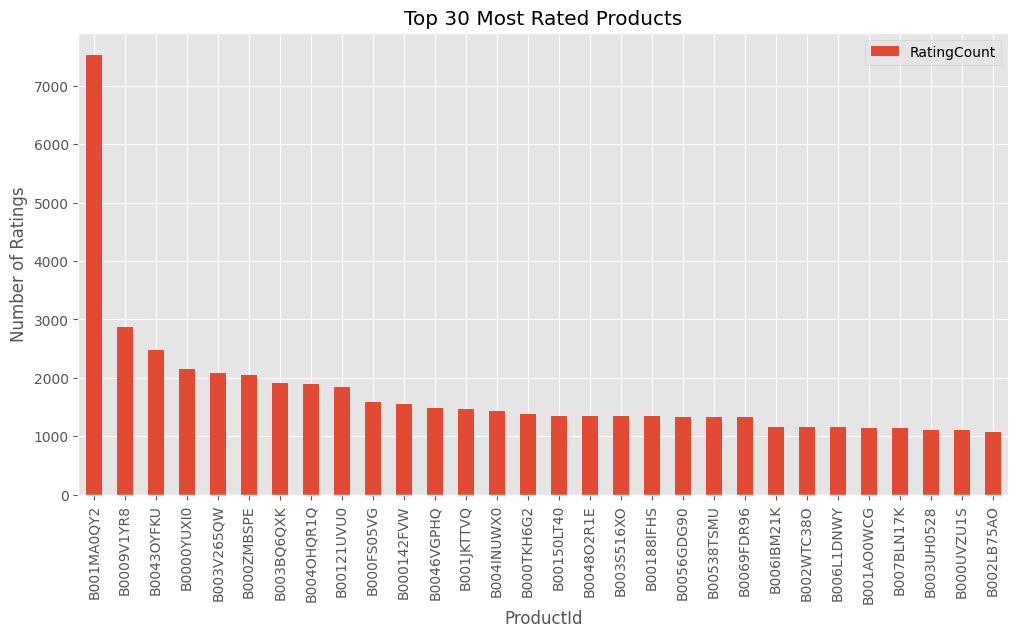


Top recommended products similar to Product ID: 6117036094

1. 0205616461
2. 0733001998
3. 0762451459
4. 1304351475
5. 1412759676
6. 1451646526
7. 1457982633
8. 1906987238
9. 1987958179
10. 3222000565


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set visualization style
plt.style.use("ggplot")

from sklearn.decomposition import TruncatedSVD

# 1. Load dataset
amazon_ratings = pd.read_csv('/content/ratings_Beauty.csv')
amazon_ratings.dropna(inplace=True)

# 2. Display most popular products
popular_products = amazon_ratings.groupby('ProductId')['Rating'].count().reset_index()
popular_products.columns = ['ProductId', 'RatingCount']
most_popular = popular_products.sort_values('RatingCount', ascending=False)

# Plot top 30 popular products
most_popular.head(30).set_index('ProductId').plot(kind="bar", figsize=(12, 6), title="Top 30 Most Rated Products")
plt.ylabel("Number of Ratings")
plt.show()

# 3. Take a subset (first 10k rows)
amazon_ratings_small = amazon_ratings.head(10000)

# Create user-item utility matrix
ratings_matrix = amazon_ratings_small.pivot_table(values='Rating', index='UserId', columns='ProductId', fill_value=0)

# Transpose for product-based similarity
X = ratings_matrix.T  # shape: (num_products, num_users)

# 4. Apply SVD
SVD = TruncatedSVD(n_components=10)
decomposed_matrix = SVD.fit_transform(X)

# 5. Calculate correlation matrix between products
correlation_matrix = np.corrcoef(decomposed_matrix)

# 6. Get recommendations for a specific product
product_names = list(X.index)

# Example product ID (must be in the dataset)
target_product_id = "6117036094"

# Check if the product exists
if target_product_id in product_names:
    product_idx = product_names.index(target_product_id)

    # Get correlation values for the target product
    correlation_product = correlation_matrix[product_idx]

    # Recommend products with correlation > 0.90 (and not the same product)
    recommended_indices = np.where((correlation_product > 0.90) & (correlation_product < 1.0))[0]
    recommended_products = [product_names[i] for i in recommended_indices]

    print(f"\nTop recommended products similar to Product ID: {target_product_id}\n")
    for i, pid in enumerate(recommended_products[:10]):
        print(f"{i+1}. {pid}")
else:
    print(f"Product ID {target_product_id} not found in the dataset.")
